In [1]:
import xarray as xr
import glob
import os
import calendar
import matplotlib.pyplot as plt
import numpy as np

In [2]:
######################################### FILE PATHS #########################################

owb_idir = '/gws/pw/j25/rep/omerrett/OWB/Analysis'
aowb_idir = '/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis'

sat_dir = "/gws/pw/j25/rep/dapa/obs_for_oscar/OCCCI-chlorophyll/"

In [3]:
# Import chlorphyll data from monthly_and_annual_average.py

AOWB = xr.open_dataset(f"{aowb_idir}/annual_surface_chloro/aowb_monthly_and_annual_surface_chloro.nc")
OWB =xr.open_dataset(f"{owb_idir}/annual_surface_chloro/owb_monthly_and_annual_surface_chloro.nc")

In [4]:
# Import OC-CCI files in a useful format

obs ={}

sat_files = sorted(glob.glob(os.path.join(sat_dir, "*2018??-*.nc")))

month_map = {f"{i:02d}": calendar.month_name[i][:3].lower() for i in range(1, 13)}

for file_path in sat_files:
    filename = os.path.basename(file_path)
    month_str = filename.split('-')[-2][-2:]

    month_key = month_map.get(month_str)

    if month_key:
        print(f"Loading {month_key} from {filename}...")
        obs[month_key] = xr.open_dataset(file_path)['chlor_a']

print('Done !')

# Interpolate satelleite data onto the grid used by the models
for m in obs.keys():
    print(f"Processing month: {m}")
    obs[m] = obs[m].interp(
    lat=AOWB.nav_lat, 
    lon=AOWB.nav_lon, 
    method='linear'
    )
print('Done!')

# Required for approriate land masking
obs[m] = obs[m].where(AOWB[f"{m}_chloro"] != 0)

# Creates an annual average of the 2018 OC-CCI data

monthly_list = [obs[m] for m in obs.keys()]

obs_combined = xr.concat(monthly_list, dim='time')
obs['annual'] = obs_combined.mean(dim='time')

Loading jan from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201801-fv5.0.nc...
Loading feb from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201802-fv5.0.nc...
Loading mar from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201803-fv5.0.nc...
Loading apr from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201804-fv5.0.nc...
Loading may from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201805-fv5.0.nc...
Loading jun from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201806-fv5.0.nc...
Loading jul from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201807-fv5.0.nc...
Loading aug from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201808-fv5.0.nc...
Loading sep from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201809-fv5.0.nc...
Loading oct from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201810-fv5.0.nc...
Loading nov from ESACCI-OC-L3S-CHLOR_A-MERGED-1M_MONTHLY_4km_GEO_PML_OCx-201811-

In [5]:
# Assemble model data into a similar structure as observations

AOWB_diff = {}
OWB_diff = {}
for m in obs.keys():
    print(f"Processing month: {m}")
    OWB_diff[m] = OWB[f"{m}_chloro"] - obs[m]
    OWB[m] = OWB[f"{m}_chloro"]
    
    AOWB_diff[m] = AOWB[f"{m}_chloro"] - obs[m]
    AOWB[m] = AOWB[f"{m}_chloro"]


print('Done !')

Processing month: jan
Processing month: feb
Processing month: mar
Processing month: apr
Processing month: may
Processing month: jun
Processing month: jul
Processing month: aug
Processing month: sep
Processing month: oct
Processing month: nov
Processing month: dec
Processing month: annual
Done !


In [6]:
# Compute seasonal bias using indices
seasons = ['JF', 'MAM', 'JJA', 'SON']
season_indices = {
    'JF': ['jan', 'feb'],
    'MAM': ['mar', 'apr', 'may'],
    'JJA': ['jun', 'jul', 'aug'],
    'SON': ['sep', 'oct', 'nov']
}

# Dictionaries to hold the computed seasonal DataArrays
owb_seasonal = {}
aowb_seasonal = {}

grid_template = OWB_diff['jan'].copy()

for s in seasons:
    keys = season_indices[s]
    
    owb_seasonal[s] = xr.concat([OWB_diff[k] for k in keys], dim='time').mean(dim='time', skipna=True)
    aowb_seasonal[s] = xr.concat([AOWB_diff[k] for k in keys], dim='time').mean(dim='time', skipna=True)

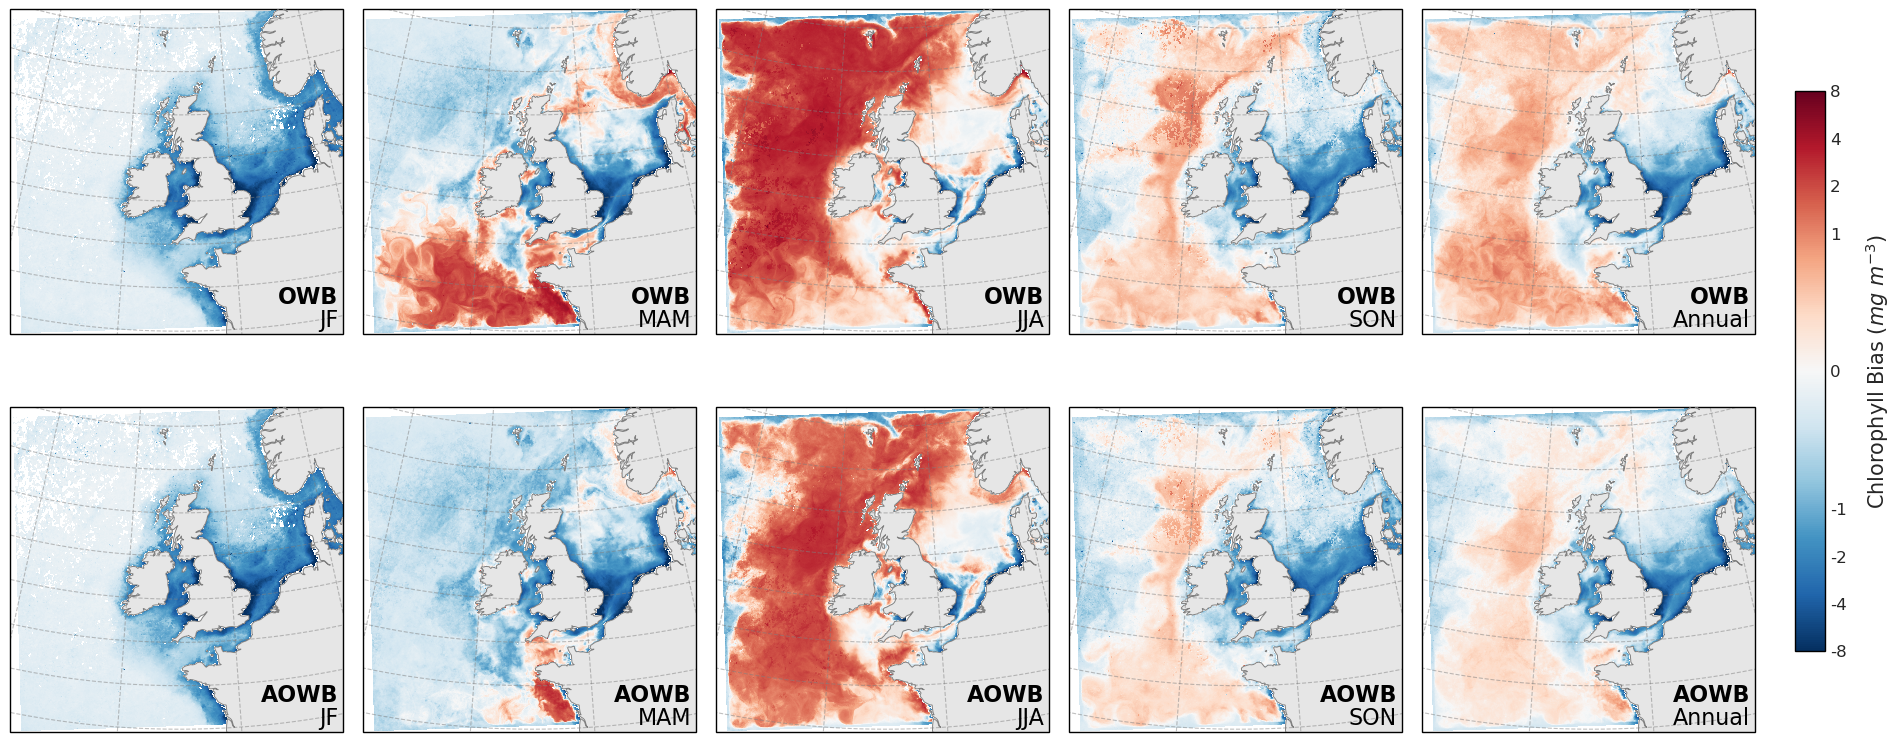

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.pyplot as plt

# Use the same plotting style throughout all plots
plt.style.use('seaborn-v0_8-whitegrid')

# Define the tight extent for the AMM15 region
TIGHT_EXTENT = [-18.5, 8, 44, 63] 

# Define the Lambert Conformal Conic (LCC) projection for a spherical look
NORTH_SEA_PROJECTION = ccrs.LambertConformal(
    central_longitude=-5,
    central_latitude=50.0,
    standard_parallels=(50.0, 60.0)
)


# Define row configurations
row_configs = [
    {'dict': owb_seasonal, "annual": OWB_diff["annual"], 'label': 'OWB'},
    {'dict': aowb_seasonal, "annual": AOWB_diff["annual"], 'label': 'AOWB'}
]

# Set up the plotting grid
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(20, 8),
    subplot_kw={'projection': NORTH_SEA_PROJECTION} 
)

# Uses a log colour bar to allow comparison across different scales
BIAS_MAX = 8
LIN_THRESH = 1
norm = colors.SymLogNorm(
        linthresh=LIN_THRESH, 
        linscale=1.0, 
        vmin=-BIAS_MAX, 
        vmax=BIAS_MAX, 
        base=5)

p_last = None

# Plotting loop made easier thanks to our data import structure
for row_idx, cfg in enumerate(row_configs):
    target_dict = cfg['dict']
    annual_data = cfg["annual"]
    row_label = cfg['label']
    
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        
        if col_idx < 4:
            s = seasons[col_idx]
            data = target_dict[s]
            col_title = s
            
        else:
            data = annual_data
            col_title = "Annual"
        
        ax.add_feature(cfeature.LAND, facecolor='#E6E6E6', zorder=1) 
        
        p_last = data.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap='RdBu_r', 
            norm=norm,
            x='lon',
            y='lat',
            add_colorbar=False,
            zorder=2
        )

        ax.set_extent(TIGHT_EXTENT, crs=ccrs.PlateCarree()) 
        ax.coastlines(resolution='50m', linewidth=0.7, color='grey', zorder=3)
        ax.gridlines(draw_labels=False, color='grey', linestyle='--', alpha=0.5) 

        # Add Season Titles only to the TOP row
        if row_idx == 0:
            ax.set_title('')
        else:
            ax.set_title('')

        # Clean up labels
        ax.set_xlabel('')
        ax.set_ylabel('')

        ax.text(
        0.985, 0.08, 
        row_label,
        transform=ax.transAxes, 
        fontsize=16, 
        fontweight='bold',
        color='black',
        ha='right',
        va = 'bottom'
        )
        ax.text(
        0.985, 0.08, 
        col_title,
        transform=ax.transAxes, 
        fontsize=16, 
        color='black',
        ha='right',
        va= 'top'
        )

        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
            

# Add a shared colourbar
plt.tight_layout()
fig.subplots_adjust(right=0.88, hspace=0.07, wspace=0.06)

cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = plt.colorbar(p_last, cax=cbar_ax, shrink=0.9, aspect=30)

cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=12)

ticks = [-8, -4, -2, -1, 0, 1, 2, 4, 8]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])
cbar.set_label('Chlorophyll Bias ($mg$ $m^{-3}$)', fontsize=15, labelpad=12)

plt.savefig('Chlorophyll_Seasonal_2x4_Bias_Matrix.png', dpi=600, bbox_inches='tight')
plt.show()